<a href="https://colab.research.google.com/github/huile09/AI.Vietnamese_banknotes/blob/main/AI_Banknotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Bài 2. Nhận diện tiền Việt Nam**


In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import os
import kagglehub

Tải dữ liệu

In [9]:
path = kagglehub.dataset_download("uylulu/vietnamese-currency-objecdetection-dataset")
print("Đường dẫn bộ dữ liệu xịn mới:", path)

100%|██████████| 118M/118M [00:00<00:00, 164MB/s]

Extracting files...


Đường dẫn bộ dữ liệu xịn mới: /root/.cache/kagglehub/datasets/uylulu/vietnamese-currency-objecdetection-dataset/versions/1


Tăng cường dữ liệu

In [10]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = os.path.join(path, 'dataset')
img_width, img_height = 128, 128
batch_size = 64

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    subset='validation'
)

Found 1972 images belonging to 11 classes.
Found 490 images belonging to 11 classes.


In [11]:
print("Thư mục gốc:", path)
print("Các thư mục con bên trong:", os.listdir(path))

Thư mục gốc: /root/.cache/kagglehub/datasets/uylulu/vietnamese-currency-objecdetection-dataset/versions/1
Các thư mục con bên trong: ['dataset']


Thiết kế mạng CNN

In [12]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(11, activation='softmax')
])

Biên dịch

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,070,379 (65.12 MB)

 Trainable params: 17,070,379 (65.12 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
epochs = 50
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.1060 - loss: 2.3886 - val_accuracy: 0.0898 - val_loss: 2.3374
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 468ms/step - accuracy: 0.1334 - loss: 2.3328 - val_accuracy: 0.1286 - val_loss: 2.3568
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 474ms/step - accuracy: 0.1547 - loss: 2.2861 - val_accuracy: 0.1429 - val_loss: 2.3523
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 466ms/step - accuracy: 0.1689 - loss: 2.2420 - val_accuracy: 0.1878 - val_loss: 2.2636
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 476ms/step - accuracy: 0.1983 - loss: 2.1759 - val_accuracy: 0.1980 - val_loss: 2.2014
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 465ms/step - accuracy: 0.2632 - loss: 2.0347 - val_accuracy: 0.2347 - val_loss: 2.0877
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 459ms/step - accuracy: 0.2941 - loss: 1.9273 - val_accuracy: 0.2837 - val_loss: 1.9986
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 466ms/step - accuracy: 0.3555 - loss: 1.7654 - val_accurac

In [1]:
from google.colab import drive
drive.mount('/content/drive')

model_path_keras = '/content/drive/MyDrive/mo_hinh_nhan_dien_tien_50_epochs2.keras'
model_path_h5 = '/content/drive/MyDrive/mo_hinh_nhan_dien_tien_50_epochs2.h5'

model.save(model_path_keras)
model.save(model_path_h5)


Mounted at /content/drive


Test

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step


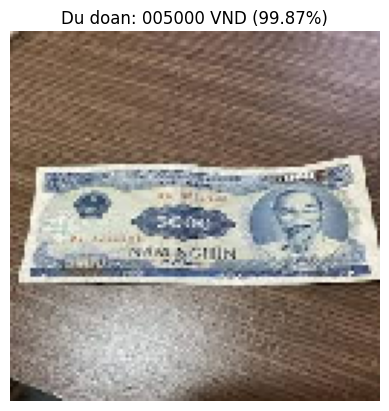

Kết quả nhận diện mệnh giá: 005000 VND
Độ tự tin (Confidence): 99.87%


In [19]:
from keras.models import load_model
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

model_path = '/content/drive/MyDrive/mo_hinh_nhan_dien_tien_50_epochs2.h5'
image_path = '/content/Anh7.jpg'

reloaded_model = load_model(model_path)

img_width, img_height = 128, 128
img = load_img(image_path, target_size=(img_width, img_height), color_mode='rgb')

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Thêm chiều batch size (1, 128, 128, 3)
img_array /= 255.0

predictions = reloaded_model.predict(img_array)
predicted_class_idx = np.argmax(predictions, axis=1)[0]
confidence = np.max(predictions) * 100

labels_map = {v: k for k, v in train_generator.class_indices.items()}
predicted_class_name = labels_map[predicted_class_idx]

plt.imshow(img)
plt.title(f"Du doan: {predicted_class_name} VND ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"Kết quả nhận diện mệnh giá: {predicted_class_name} VND")
print(f"Độ tự tin (Confidence): {confidence:.2f}%")

In [20]:
labels_map = {v: k for k, v in train_generator.class_indices.items()}

In [91]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = os.path.join(path, 'dataset')
img_width, img_height = 128, 128
batch_size = 64

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

validation_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

val_loss, val_acc = model.evaluate(validation_generator)

print(f"Validation Loss (Độ lỗi): {val_loss:.4f}")
print(f"Validation Accuracy (Độ chính xác thực tế): {val_acc * 100:.2f}%")

Found 490 images belonging to 11 classes.
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.7694 - loss: 0.6827
Validation Loss (Độ lỗi): 0.6827
Validation Accuracy (Độ chính xác thực tế): 76.94%


In [20]:
# In ra thứ tự nhãn chuẩn mà Keras đã tự sắp xếp khi quét thư mục
print(train_generator.class_indices)

{'000200': 0, '000500': 1, '001000': 2, '002000': 3, '005000': 4, '010000': 5, '020000': 6, '050000': 7, '100000': 8, '200000': 9, '500000': 10}
